# Выполнил

Неустроев Сергей, 409232



In [ ]:
# @title Импоррт библиотек

import numpy as np
import matplotlib.pyplot as plt
import tracemalloc
from typing import Callable, Tuple, Optional
import time

<a id='1-def'></a>
# Функции выбранные для расмотрения

In [ ]:
# @title Функция Розенберга $f(x, y) = (1-x)^2+100(y-x^2)^2$

def rosenbrock(x: np.ndarray) -> Tuple[float, np.ndarray]:

    x1, x2 = x[0], x[1]
    # Значение функции
    term1 = (1.0 - x1) ** 2
    term2 = 100.0 * (x2 - x1 ** 2) ** 2
    f = term1 + term2

    # Градиент
    df_dx1 = -2.0 * (1.0 - x1) - 400.0 * x1 * (x2 - x1 ** 2)
    df_dx2 = 200.0 * (x2 - x1 ** 2)
    grad = np.array([df_dx1, df_dx2])
    return f, grad

In [ ]:
# @title Функция Экле $f(x,y)=-20\exp[-0.2\sqrt{0.5(x^2+y^2)}]-\exp[0.5(cos(2\pi x)+\cos(2\pi y))]+e+20$

_adam_result = {}


def ackley(x: np.ndarray) -> Tuple[float, np.ndarray]:

    a, b, c = 20.0, 0.2, 2.0 * np.pi
    d = len(x)  # здесь d=2
    sum_sq = np.sum(x**2)
    sum_cos = np.sum(np.cos(c * x))

    # Значение функции
    term1 = -a * np.exp(-b * np.sqrt(sum_sq / d))
    term2 = -np.exp(sum_cos / d)
    f_val = term1 + term2 + a + np.exp(1.0)

    # Градиент
    sqrt_sum_sq = np.sqrt(sum_sq / d)
    # Общий множитель для первой экспоненты
    if sqrt_sum_sq == 0:
        # В нуле градиент равен нулю (устраним деление на ноль)
        grad_term1 = np.zeros(d)
    else:
        grad_term1 = (a * b * np.exp(-b * sqrt_sum_sq) / (d * sqrt_sum_sq)) * x

    # Производная второй экспоненты
    grad_term2 = (c * np.exp(sum_cos / d) / d) * np.sin(c * x)

    grad = grad_term1 + grad_term2
    return f_val, grad

In [ ]:
# @title Загадочная кусочная функция $\frac{1}{2}\left(\left(\left(x\left(\operatorname{round}\left(\sin10y\right)+2\right)\right)^{2}+y-10\right)^{2} + \left(x+\left(y\left(\operatorname{round}\left(\sin7x\right)+2\right)\right)^{2}-7\right)^{2}\right)=z$
def custom_func(x: np.ndarray) -> Tuple[float, np.ndarray]:

    x_val, y_val = x[0], x[1]

    # Дискретные компоненты (считаем локально постоянными)
    c1 = np.round(np.sin(10.0 * y_val))
    c2 = np.round(np.sin(7.0 * x_val))
    a = c1 + 2.0
    b = c2 + 2.0

    # Выражения A и B
    A = (x_val * a) ** 2 + y_val - 10.0
    B = x_val + (y_val * b) ** 2 - 7.0

    f = 0.5 * (A ** 2 + B ** 2)

    # Градиент (учитываем, что c1, c2 не зависят от x,y)
    dA_dx = 2.0 * a ** 2 * x_val
    dB_dx = 1.0
    dA_dy = 1.0
    dB_dy = 2.0 * b ** 2 * y_val

    df_dx = A * dA_dx + B * dB_dx
    df_dy = A * dA_dy + B * dB_dy

    grad = np.array([df_dx, df_dy])
    return f, grad

<a id='2-alg'></a>
# Реализованные алгоритмы

In [ ]:
# @title Алгоритм градиентного спуска с моментом

_momentum_result = {}

def momentum(
    func: Callable[[np.ndarray], Tuple[float, np.ndarray]],
    x0: np.ndarray,
    alpha: float = 0.01,
    beta: float = 0.9,
    max_iter: int = 10000,
    tol_grad: float = 1e-6,
    tol_f: float = 1e-12,
    verbose: bool = False,
) -> dict:

    x = x0.copy().astype(float)
    v = np.zeros_like(x)

    history_f = []
    history_grad_norm = []
    times = []
    grad_calls = 0

    tracemalloc.start()
    start_time = time.perf_counter()

    converged = False
    n_iter = 0
    final_f = None

    for t in range(1, max_iter + 1):
        # Проверка на слишком большие значения x
        if np.any(np.abs(x) > 1e5):
            if verbose:
                print(f"Итерация {t}: x вышел за пределы, остановка")
            break

        f_val, grad = func(x)
        grad_calls += 1

        # Проверка на конечность
        if not np.isfinite(f_val) or not np.all(np.isfinite(grad)):
            if verbose:
                print(f"Итерация {t}: переполнение, уменьшаем alpha")
            alpha *= 0.5
            if alpha < 1e-12:
                break
            continue

        final_f = f_val
        history_f.append(f_val)
        grad_norm = np.linalg.norm(grad)
        history_grad_norm.append(grad_norm)
        times.append(time.perf_counter() - start_time)

        if grad_norm < tol_grad:
            n_iter = t
            converged = True
            break

        # Градиентный клиппинг (как в методе Нестерова)
        if grad_norm > 1e4:
            grad = (grad / grad_norm) * 1e4

        # Обновление скорости с моментом
        v = beta * v - alpha * grad
        x_new = x + v

        # Проверка на переполнение после обновления
        if np.any(np.abs(x_new) > 1e5) or np.any(~np.isfinite(x_new)):
            if verbose:
                print(f"Итерация {t}: x_new содержит недопустимые значения, уменьшаем alpha")
            alpha *= 0.5
            if alpha < 1e-12:
                break
            continue

        x = x_new

    if not converged:
        n_iter = t if 't' in locals() else max_iter

    exec_time = time.perf_counter() - start_time
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    peak_memory = peak

    # Относительное снижение на последних 10% итераций
    k = max(1, len(history_f) // 10)
    f_prev = history_f[-k] if len(history_f) >= k else history_f[0]
    f_last = history_f[-1] if history_f else np.nan
    if f_prev != 0 and not np.isnan(f_last):
        relative_decrease = (f_prev - f_last) / f_prev
    else:
        relative_decrease = 0.0

    result = {
        'x_opt': x,
        'f_opt': final_f if final_f is not None else np.nan,
        'n_iter': n_iter,
        'converged': converged,
        'history_f': np.array(history_f),
        'history_grad': np.array(history_grad_norm),
        'times': np.array(times),
        'peak_memory_bytes': peak_memory,
        'true_minimum': 0.0,
        'execution_time': exec_time,
        'relative_decrease': relative_decrease,
        'distance_to_min': np.linalg.norm(x - np.zeros_like(x)),
        'total_func_calls': grad_calls,
        'integral_cost': grad_calls,
    }
    return result

def momentum_def(f: Callable = None) -> None:

    if f is None:
        f = ackley

    x0 = np.array([5.0, 5.0])
    alpha = 0.01
    beta = 0.9
    max_iter = 500000
    tol_grad = 1e-8

    result = momentum(
        func=f,
        x0=x0,
        alpha=alpha,
        beta=beta,
        max_iter=max_iter,
        tol_grad=tol_grad,
        verbose=False
    )

    global _momentum_result
    _momentum_result = result

def momentum_info() -> None:

    if not _momentum_result:
        print("Ошибка: сначала запустите momentum_def().")
        return

    res = _momentum_result
    f_opt = res['f_opt']
    n_iter = res['n_iter']
    peak_mem = res['peak_memory_bytes']
    true_min = res['true_minimum']

    diff_sq = (f_opt - true_min) ** 2

    print("=" * 60)
    print("РЕЗУЛЬТАТЫ ОПТИМИЗАЦИИ МЕТОДОМ ГРАДИЕНТНОГО СПУСКА С МОМЕНТОМ")
    print("=" * 60)
    print(f"Число итераций до сходимости: {n_iter}")
    print(f"Найденное значение f(x): {f_opt:.12e}")
    print(f"Истинный минимум f*: {true_min}")
    print(f"Квадрат разности (f - f*)^2: {diff_sq:.12e}")
    print(f"Пиковое потребление памяти: {peak_mem / 1024:.2f} КБ ({peak_mem} байт)")
    print(f"Фактическое время выполнения: {res['execution_time']:.4f} сек")
    print(f"Относительное снижение на последних итерациях: {res['relative_decrease']:.6e}")
    print(f"Евклидово расстояние до минимума: {res['distance_to_min']:.6e}")
    print(f"Всего вычислений градиента: {res['total_func_calls']}")
    print(f"Интегральная оценка вычислительных затрат: {res['integral_cost']}")
    if res['converged']:
        print("Статус: сошёлся по градиентному критерию.")
    else:
        print("Статус: достигнуто максимальное число итераций или произошла расходимость.")
    print("=" * 60)

    if len(res['history_f']) > 0:
        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.semilogy(res['history_f'], linewidth=1.5, color='blue')
        plt.xlabel('Итерация')
        plt.ylabel('f(x) (лог. шкала)')
        plt.title('Сходимость функции по итерациям')
        plt.grid(True, alpha=0.3)

        plt.subplot(1, 2, 2)
        plt.semilogy(res['times'], res['history_f'], linewidth=1.5, color='green')
        plt.xlabel('Время (сек)')
        plt.ylabel('f(x) (лог. шкала)')
        plt.title('Сходимость функции по времени')
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
    else:
        print("Нет данных для построения графиков (алгоритм сразу разошёлся).")

In [ ]:
# @title Алгоритм Adam

def adam(
    func: Callable[[np.ndarray], Tuple[float, np.ndarray]],
    x0: np.ndarray,
    alpha: float = 0.01,
    beta1: float = 0.9,
    beta2: float = 0.999,
    eps: float = 1e-8,
    max_iter: int = 10000,
    tol_grad: float = 1e-6,
    tol_f: float = 1e-12,
    verbose: bool = False,
) -> dict:
    x = x0.copy().astype(float)
    d = len(x)
    m = np.zeros(d)
    v = np.zeros(d)

    history_f = []
    history_grad_norm = []
    times = []                     # список накопленного времени на каждой итерации
    grad_calls = 0                 # счётчик вызовов func

    tracemalloc.start()
    start_time = time.perf_counter()

    converged = False
    n_iter = 0
    final_f = None

    for t in range(1, max_iter + 1):
        f_val, grad = func(x)
        grad_calls += 1
        final_f = f_val
        history_f.append(f_val)
        grad_norm = np.linalg.norm(grad)
        history_grad_norm.append(grad_norm)
        times.append(time.perf_counter() - start_time)

        if grad_norm < tol_grad:
            n_iter = t
            converged = True
            break

        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * (grad ** 2)

        m_hat = m / (1 - beta1 ** t)
        v_hat = v / (1 - beta2 ** t)

        x -= alpha * m_hat / (np.sqrt(v_hat) + eps)

    if not converged:
        n_iter = max_iter

    exec_time = time.perf_counter() - start_time
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    peak_memory = peak

    # Относительное снижение на последних 10% итераций
    k = max(1, len(history_f) // 10)
    f_prev = history_f[-k] if len(history_f) >= k else history_f[0]
    f_last = history_f[-1]
    if f_prev != 0:
        relative_decrease = (f_prev - f_last) / f_prev
    else:
        relative_decrease = 0.0

    result = {
        'x_opt': x,
        'f_opt': final_f,
        'n_iter': n_iter,
        'converged': converged,
        'history_f': np.array(history_f),
        'history_grad': np.array(history_grad_norm),
        'times': np.array(times),
        'peak_memory_bytes': peak_memory,
        'true_minimum': 0.0,
        'execution_time': exec_time,
        'relative_decrease': relative_decrease,
        'distance_to_min': np.linalg.norm(x - np.zeros_like(x)),   # минимум в (0,...,0)
        'total_func_calls': grad_calls,
        'integral_cost': grad_calls,      # интегральная оценка = число вызовов
    }
    return result

# Функция-обёртка для запуска Adam на функции Экли

def adam_def(f: Callable = None) -> None:

    if f is None:
        f = ackley

    # Начальная точка (достаточно далеко от нуля для демонстрации)
    x0 = np.array([5.0, 5.0])

    # Параметры Adam
    alpha = 0.01        # шаг
    max_iter = 50000
    tol_grad = 1e-8

    # Запуск оптимизации
    result = adam(
        func=f,
        x0=x0,
        alpha=alpha,
        max_iter=max_iter,
        tol_grad=tol_grad,
        verbose=True
    )

    # Сохраняем результат в глобальной переменной
    global _adam_result
    _adam_result = result

# Функция вывода аналитики

def adam_info() -> None:
    if not _adam_result:
        print("Ошибка: сначала запустите adam_def().")
        return

    res = _adam_result
    f_opt = res['f_opt']
    n_iter = res['n_iter']
    peak_mem = res['peak_memory_bytes']
    true_min = res['true_minimum']

    diff_sq = (f_opt - true_min) ** 2

    print("=" * 60)
    print("РЕЗУЛЬТАТЫ ОПТИМИЗАЦИИ АЛГОРИТМОМ ADAM")
    print("=" * 60)
    print(f"Число итераций до сходимости: {n_iter}")
    print(f"Найденное значение f(x): {f_opt:.12e}")
    print(f"Истинный минимум f*: {true_min}")
    print(f"Квадрат разности (f - f*)^2: {diff_sq:.12e}")
    print(f"Пиковое потребление памяти: {peak_mem / 1024:.2f} КБ ({peak_mem} байт)")
    print(f"Фактическое время выполнения: {res['execution_time']:.4f} сек")
    print(f"Относительное снижение на последних итерациях: {res['relative_decrease']:.6e}")
    print(f"Евклидово расстояние до минимума: {res['distance_to_min']:.6e}")
    print(f"Всего вычислений градиента: {res['total_func_calls']}")
    print(f"Интегральная оценка вычислительных затрат: {res['integral_cost']}")
    if res['converged']:
        print("Статус: сошёлся по градиентному критерию.")
    else:
        print("Статус: достигнуто максимальное число итераций.")
    print("=" * 60)

    # Построение графиков
    plt.figure(figsize=(12, 5))

    # График значения функции от итераций (логарифм)
    plt.subplot(1, 2, 1)
    plt.semilogy(res['history_f'], linewidth=1.5, color='blue')
    plt.xlabel('Итерация')
    plt.ylabel('f(x) (лог. шкала)')
    plt.title('Сходимость функции по итерациям')
    plt.grid(True, alpha=0.3)

    # График значения функции от времени выполнения
    plt.subplot(1, 2, 2)
    plt.semilogy(res['times'], res['history_f'], linewidth=1.5, color='green')
    plt.xlabel('Время (сек)')
    plt.ylabel('f(x) (лог. шкала)')
    plt.title('Сходимость функции по времени')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
# @title Алгоритм Нестерова

_nesterov_result = {}

def nesterov(
    func: Callable[[np.ndarray], Tuple[float, np.ndarray]],
    x0: np.ndarray,
    alpha0: float = 1.0,
    max_iter: int = 5000,
    tol_grad: float = 1e-8,
    backtrack_c: float = 1e-4,
    backtrack_rho: float = 0.5,
    verbose: bool = False,
) -> dict:

    x = x0.copy().astype(float)
    d = len(x)
    t = 1.0
    y = x.copy()

    history_f = []
    history_grad_norm = []
    times = []                     # накопленное время на каждой итерации
    func_calls = 0                 # счётчик вызовов func

    x_prev = x.copy()

    tracemalloc.start()
    start_time = time.perf_counter()

    converged = False
    n_iter = 0
    final_f = None

    alpha = alpha0

    for k in range(1, max_iter + 1):
        f_x, grad_x = func(x)
        func_calls += 1
        history_f.append(f_x)
        grad_norm = np.linalg.norm(grad_x)
        history_grad_norm.append(grad_norm)
        times.append(time.perf_counter() - start_time)

        if not np.isfinite(f_x):
            break

        if grad_norm < tol_grad:
            n_iter = k
            converged = True
            final_f = f_x
            break

        f_y, grad_y = func(y)
        func_calls += 1

        # Защита от переполнения
        if not np.isfinite(f_y) or not np.all(np.isfinite(grad_y)):
            y = x.copy()
            t = 1.0
            f_y, grad_y = func(y)
            func_calls += 1
            if not np.isfinite(f_y):
                break

        # Gradient clipping
        grad_y_norm = np.linalg.norm(grad_y)
        if grad_y_norm > 1e4:
            grad_y = (grad_y / grad_y_norm) * 1e4

        while True:
            x_candidate = y - alpha * grad_y
            f_candidate, _ = func(x_candidate)
            func_calls += 1

            if not np.isfinite(f_candidate):
                alpha *= backtrack_rho
                continue

            armijo_rhs = f_y - backtrack_c * alpha * np.dot(grad_y, grad_y)
            if f_candidate <= armijo_rhs or alpha < 1e-15:
                break
            alpha *= backtrack_rho

        x_new = x_candidate

        if alpha < 1e-10:
            alpha = 1.0
        else:
            alpha = min(1.0, alpha / backtrack_rho)

        # Адаптивный рестарт
        if f_candidate > f_x:
            t_next = 1.0
        else:
            t_next = (1.0 + np.sqrt(1.0 + 4.0 * t * t)) / 2.0

        weight = (t - 1.0) / t_next
        y_next = x_new + weight * (x_new - x_prev)

        x_prev = x
        x = x_new
        y = y_next
        t = t_next

    if not converged:
        n_iter = max_iter
        f_x, _ = func(x)
        func_calls += 1
        final_f = f_x if np.isfinite(f_x) else final_f

    exec_time = time.perf_counter() - start_time
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    peak_memory = peak

    # Относительное снижение на последних итерациях
    k_len = max(1, len(history_f) // 10)
    f_prev = history_f[-k_len] if len(history_f) >= k_len else history_f[0]
    f_last = history_f[-1]
    if f_prev != 0:
        relative_decrease = (f_prev - f_last) / f_prev
    else:
        relative_decrease = 0.0

    result = {
        'x_opt': x,
        'f_opt': final_f,
        'n_iter': n_iter,
        'converged': converged,
        'history_f': np.array(history_f),
        'history_grad': np.array(history_grad_norm),
        'times': np.array(times),
        'peak_memory_bytes': peak_memory,
        'true_minimum': 0.0,
        'execution_time': exec_time,
        'relative_decrease': relative_decrease,
        'distance_to_min': np.linalg.norm(x - np.zeros_like(x)),
        'total_func_calls': func_calls,
        'integral_cost': func_calls,
    }
    return result

# обёртка для запуска Нестерова на функции Экли

def nesterov_def(f: Callable = None) -> None:

    if f is None:
        f = ackley

    x0 = np.array([5.0, 5.0])   # та же начальная точка, что и в Adam
    # Параметры
    alpha0 = 1.0
    max_iter = 100000
    tol_grad = 1e-8

    result = nesterov(
        func=f,
        x0=x0,
        alpha0=alpha0,
        max_iter=max_iter,
        tol_grad=tol_grad,
        verbose=False
    )

    global _nesterov_result
    _nesterov_result = result

# Функция вывода статистики для Нестерова

def nesterov_info() -> None:
    if not _nesterov_result:
        print("Ошибка: сначала запустите nesterov_def().")
        return

    res = _nesterov_result
    f_opt = res['f_opt']
    n_iter = res['n_iter']
    peak_mem = res['peak_memory_bytes']
    true_min = res['true_minimum']

    diff_sq = (f_opt - true_min) ** 2

    print("=" * 60)
    print("РЕЗУЛЬТАТЫ ОПТИМИЗАЦИИ МЕТОДОМ НЕСТЕРОВА")
    print("=" * 60)
    print(f"Число итераций до сходимости: {n_iter}")
    print(f"Найденное значение f(x): {f_opt:.12e}")
    print(f"Истинный минимум f*: {true_min}")
    print(f"Квадрат разности (f - f*)^2: {diff_sq:.12e}")
    print(f"Пиковое потребление памяти: {peak_mem / 1024:.2f} КБ ({peak_mem} байт)")
    print(f"Фактическое время выполнения: {res['execution_time']:.4f} сек")
    print(f"Относительное снижение на последних итерациях: {res['relative_decrease']:.6e}")
    print(f"Евклидово расстояние до минимума: {res['distance_to_min']:.6e}")
    print(f"Всего вычислений градиента: {res['total_func_calls']}")
    print(f"Интегральная оценка вычислительных затрат: {res['integral_cost']}")
    if res['converged']:
        print("Статус: сошёлся по градиентному критерию.")
    else:
        print("Статус: достигнуто максимальное число итераций.")
    print("=" * 60)

    # Графики
    plt.figure(figsize=(12, 5))

    # График от итераций
    plt.subplot(1, 2, 1)
    plt.semilogy(res['history_f'], linewidth=1.5, color='blue')
    plt.xlabel('Итерация')
    plt.ylabel('f(x) (лог. шкала)')
    plt.title('Сходимость функции по итерациям')
    plt.grid(True, alpha=0.3)

    # График от времени
    plt.subplot(1, 2, 2)
    plt.semilogy(res['times'], res['history_f'], linewidth=1.5, color='green')
    plt.xlabel('Время (сек)')
    plt.ylabel('f(x) (лог. шкала)')
    plt.title('Сходимость функции по времени')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

 # Результат работы алгоритмов

## Алгоритм градиентного спуска с моментом

РЕЗУЛЬТАТЫ ОПТИМИЗАЦИИ МЕТОДОМ ГРАДИЕНТНОГО СПУСКА С МОМЕНТОМ
Число итераций до сходимости: 279
Найденное значение f(x): 1.263226899152e+01
Истинный минимум f*: 0.0
Квадрат разности (f - f*)^2: 1.595742198740e+02
Пиковое потребление памяти: 27.76 КБ (28425 байт)
Фактическое время выполнения: 0.1066 сек
Относительное снижение на последних итерациях: 1.828067e-15
Евклидово расстояние до минимума: 7.051524e+00
Всего вычислений градиента: 279
Интегральная оценка вычислительных затрат: 279
Статус: сошёлся по градиентному критерию.


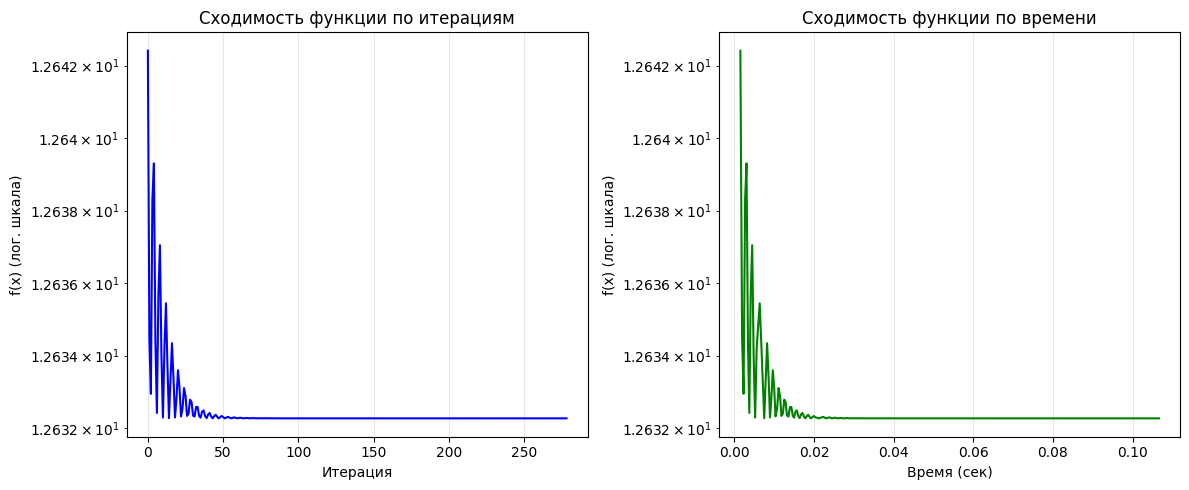

In [ ]:
# @title Запуск Momentum на функции Экли

momentum_def()
momentum_info()

РЕЗУЛЬТАТЫ ОПТИМИЗАЦИИ МЕТОДОМ ГРАДИЕНТНОГО СПУСКА С МОМЕНТОМ
Число итераций до сходимости: 500000
Найденное значение f(x): 1.765342873957e+11
Истинный минимум f*: 0.0
Квадрат разности (f - f*)^2: 3.116435462629e+22
Пиковое потребление памяти: 47366.38 КБ (48503178 байт)
Фактическое время выполнения: 123.9077 сек
Относительное снижение на последних итерациях: 6.254800e-01
Евклидово расстояние до минимума: 1.973392e+02
Всего вычислений градиента: 500000
Интегральная оценка вычислительных затрат: 500000
Статус: достигнуто максимальное число итераций или произошла расходимость.


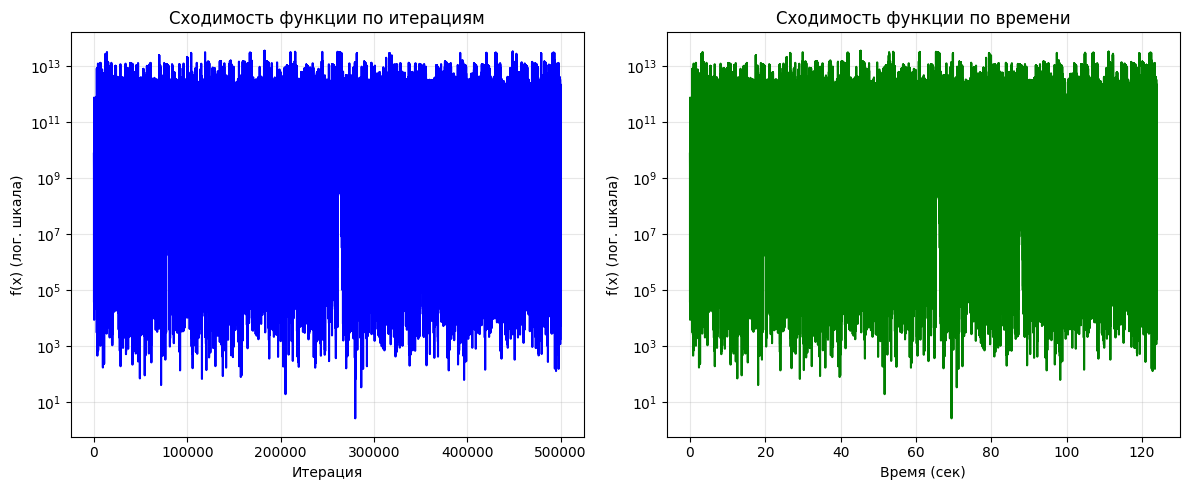

In [ ]:
# @title Запуск Momentum на функции Розенброка

momentum_def(rosenbrock)
momentum_info()

РЕЗУЛЬТАТЫ ОПТИМИЗАЦИИ МЕТОДОМ ГРАДИЕНТНОГО СПУСКА С МОМЕНТОМ
Число итераций до сходимости: 500000
Найденное значение f(x): 1.157598345775e+08
Истинный минимум f*: 0.0
Квадрат разности (f - f*)^2: 1.340033930141e+16
Пиковое потребление памяти: 47365.04 КБ (48501801 байт)
Фактическое время выполнения: 170.2793 сек
Относительное снижение на последних итерациях: 2.253276e-01
Евклидово расстояние до минимума: 4.416914e+01
Всего вычислений градиента: 500000
Интегральная оценка вычислительных затрат: 500000
Статус: достигнуто максимальное число итераций или произошла расходимость.


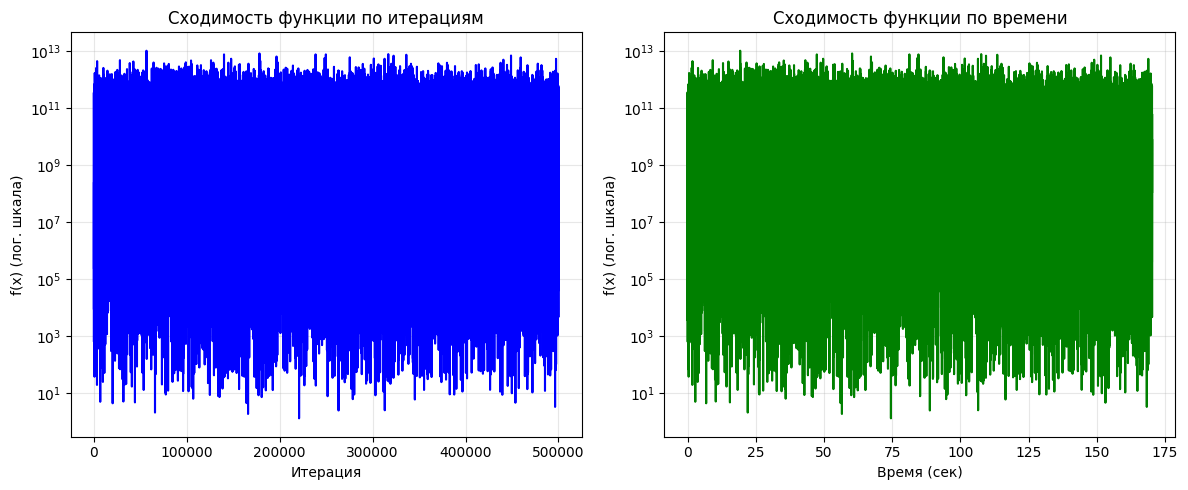

In [ ]:
# @title Запуск Momentum на загадочной функции

momentum_def(custom_func)
momentum_info()

## Алгоритм Adam

РЕЗУЛЬТАТЫ ОПТИМИЗАЦИИ АЛГОРИТМОМ ADAM
Число итераций до сходимости: 297
Найденное значение f(x): 1.263226899152e+01
Истинный минимум f*: 0.0
Квадрат разности (f - f*)^2: 1.595742198740e+02
Пиковое потребление памяти: 30.45 КБ (31178 байт)
Фактическое время выполнения: 0.0942 сек
Относительное снижение на последних итерациях: 1.406206e-16
Евклидово расстояние до минимума: 7.051524e+00
Всего вычислений градиента: 297
Интегральная оценка вычислительных затрат: 297
Статус: сошёлся по градиентному критерию.


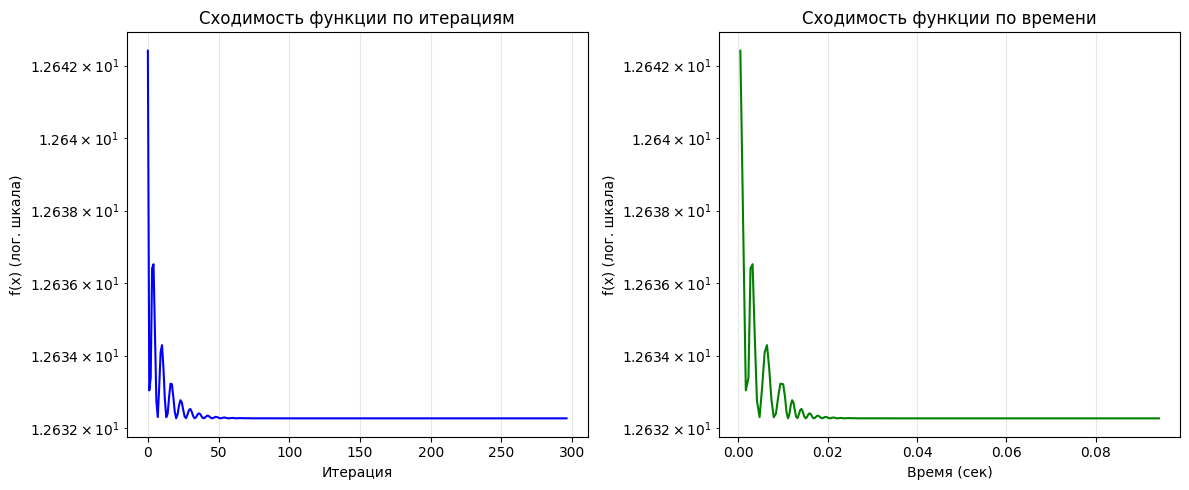

In [ ]:
# @title Запуск Adam на функции Экли

adam_def()
adam_info()

РЕЗУЛЬТАТЫ ОПТИМИЗАЦИИ АЛГОРИТМОМ ADAM
Число итераций до сходимости: 17922
Найденное значение f(x): 5.113244244090e-17
Истинный минимум f*: 0.0
Квадрат разности (f - f*)^2: 2.614526669972e-33
Пиковое потребление памяти: 1712.55 КБ (1753651 байт)
Фактическое время выполнения: 2.8646 сек
Относительное снижение на последних итерациях: 1.000000e+00
Евклидово расстояние до минимума: 1.414214e+00
Всего вычислений градиента: 17922
Интегральная оценка вычислительных затрат: 17922
Статус: сошёлся по градиентному критерию.


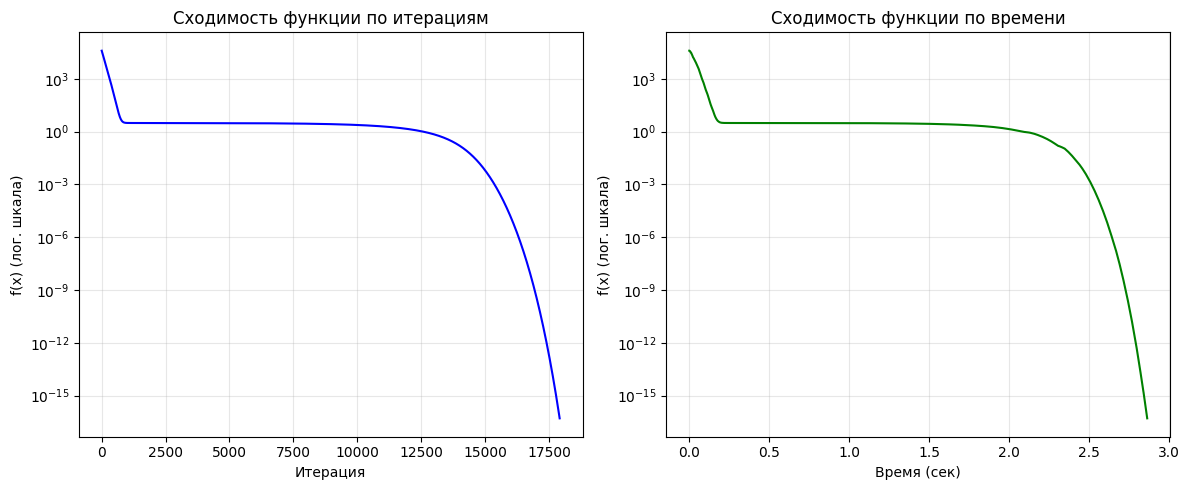

In [ ]:
# @title Запуск Adam на функции Розенберга

adam_def(rosenbrock)
adam_info()

РЕЗУЛЬТАТЫ ОПТИМИЗАЦИИ АЛГОРИТМОМ ADAM
Число итераций до сходимости: 7237
Найденное значение f(x): 2.394591129017e-19
Истинный минимум f*: 0.0
Квадрат разности (f - f*)^2: 5.734066675168e-38
Пиковое потребление памяти: 686.91 КБ (703392 байт)
Фактическое время выполнения: 1.6932 сек
Относительное снижение на последних итерациях: 1.000000e+00
Евклидово расстояние до минимума: 1.298461e+00
Всего вычислений градиента: 7237
Интегральная оценка вычислительных затрат: 7237
Статус: сошёлся по градиентному критерию.


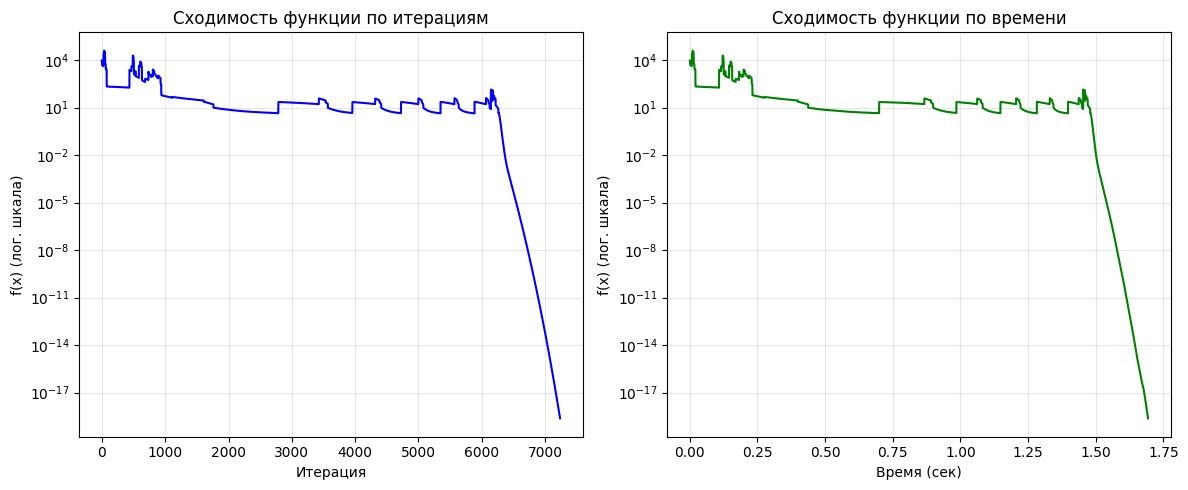

In [ ]:
# @title Запуск Adam на загадочной фукции

adam_def(custom_func)
adam_info()

## Алгоритм Нестерова

РЕЗУЛЬТАТЫ ОПТИМИЗАЦИИ МЕТОДОМ НЕСТЕРОВА
Число итераций до сходимости: 216
Найденное значение f(x): 1.263226899152e+01
Истинный минимум f*: 0.0
Квадрат разности (f - f*)^2: 1.595742198740e+02
Пиковое потребление памяти: 22.24 КБ (22776 байт)
Фактическое время выполнения: 0.1959 сек
Относительное снижение на последних итерациях: 1.406206e-16
Евклидово расстояние до минимума: 7.051524e+00
Всего вычислений градиента: 866
Интегральная оценка вычислительных затрат: 866
Статус: сошёлся по градиентному критерию.


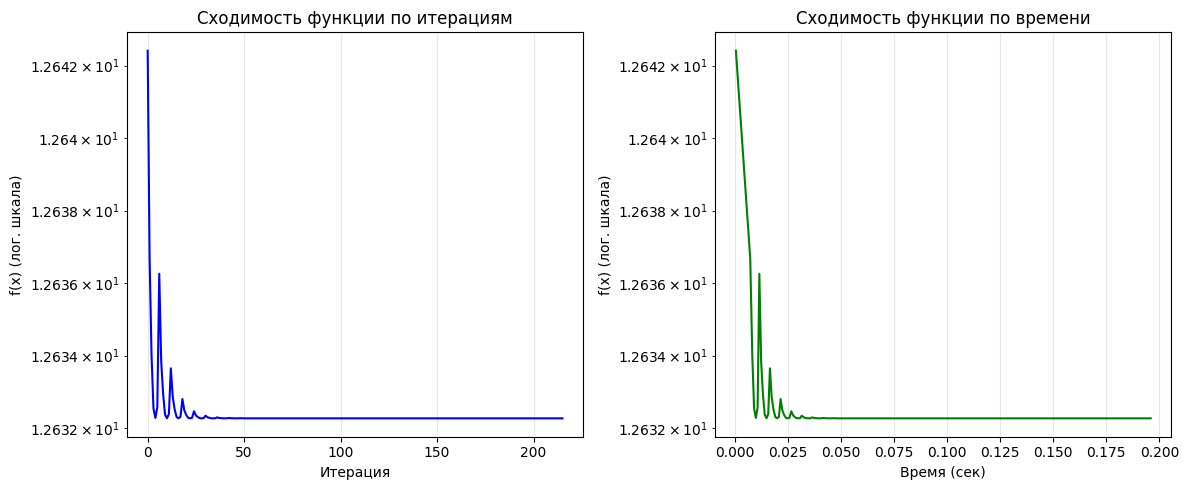

In [ ]:
# @title Запуск алгоритма Нестерова на функции Экле

nesterov_def()
nesterov_info()

РЕЗУЛЬТАТЫ ОПТИМИЗАЦИИ МЕТОДОМ НЕСТЕРОВА
Число итераций до сходимости: 100000
Найденное значение f(x): 5.191129319959e+03
Истинный минимум f*: 0.0
Квадрат разности (f - f*)^2: 2.694782361654e+07
Пиковое потребление памяти: 9380.34 КБ (9605464 байт)
Фактическое время выполнения: 39.2415 сек
Относительное снижение на последних итерациях: -2.388809e-04
Евклидово расстояние до минимума: 5.047262e+03
Всего вычислений градиента: 400021
Интегральная оценка вычислительных затрат: 400021
Статус: достигнуто максимальное число итераций.


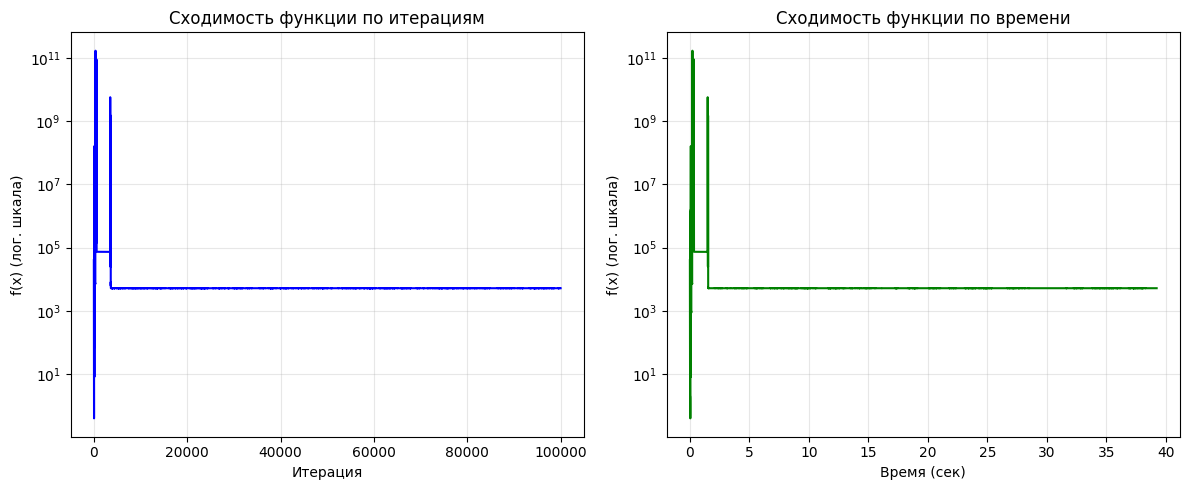

In [ ]:
# @title Запуск алгоритма Нестерова на функции Розенберга

nesterov_def(rosenbrock)
nesterov_info()

РЕЗУЛЬТАТЫ ОПТИМИЗАЦИИ МЕТОДОМ НЕСТЕРОВА
Число итераций до сходимости: 113
Найденное значение f(x): 3.446333851941e-20
Истинный минимум f*: 0.0
Квадрат разности (f - f*)^2: 1.187721701904e-39
Пиковое потребление памяти: 14.50 КБ (14844 байт)
Фактическое время выполнения: 0.1039 сек
Относительное снижение на последних итерациях: 9.997523e-01
Евклидово расстояние до минимума: 1.298461e+00
Всего вычислений градиента: 456
Интегральная оценка вычислительных затрат: 456
Статус: сошёлся по градиентному критерию.


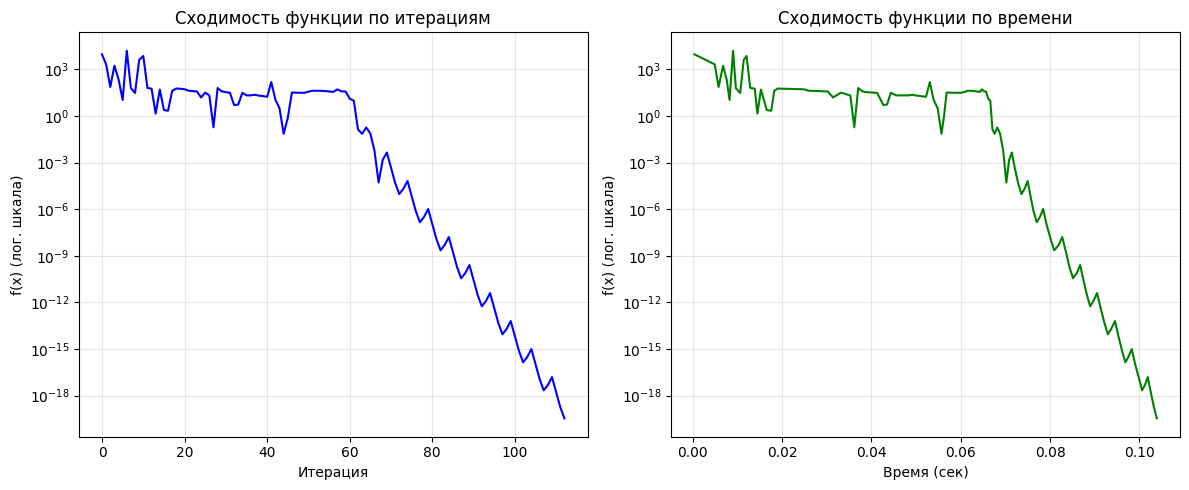

In [ ]:
# @title Запуск алгоритма Нестерова на загадочной функции

nesterov_def(custom_func)
nesterov_info()

# Вывод

Из данных по сходимости функции становиться очевидно, что наиболее эффективнм является алгоритм ADAM.